This notebook is used to find and compare the confidence intervals of the rates from different COMPAS simulations

In [1]:
#imports!

# let's import things
import h5py as h5 
import pandas as pd
from astropy.table import Table
from astropy import units as u
from astropy import constants as const
import numpy as np
import matplotlib.pyplot as plt
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
import sys
import os
from scipy import stats
import seaborn as sns
import matplotlib as mpl
import tol_colors as tc

# Add the subdir to sys.path for our created scripts
sys.path.append('/home/msantiago/research_work/useful_py_scripts/')
sys.path.append('/home/msantiago/research_work/making_figures/paper_figures/')

# Now you can import the module
import useful_fncs
import utils_from_others
import figure_utils

# import for axes labels 
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

We are first going to do boostrapping on the fbin = fixed

In [97]:
# let's read in our files 

## NSNS optimized run

# let's first look at the NSNS_output
pathToH5_NSNS = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS  = h5.File(pathToH5_NSNS, "r")

DCOs_NSNS = Data_NSNS['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

# making sure we are rpesenting the true universe
mixture_weights_all = DCOs_NSNS['mixture_weight'][()]
mixture_weights = mixture_weights_all[DCO_mask_NSNS]

# times (these should be in Myr)
lifetimes_all = DCOs_NSNS['Time'][()]
lifetimes = lifetimes_all[DCO_mask_NSNS]

col_times_all = DCOs_NSNS['Coalescence_Time'][()]
col_times = col_times_all[DCO_mask_NSNS]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times = lifetimes + col_times


In [98]:
# doing the same for WDWD optimized rate

pathToH5_WDWD = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD  = h5.File(pathToH5_WDWD, "r")

DCOs_WDWD = Data_WDWD['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

# making sure we are rpesenting the true universe
mixture_weights_all_WDWD = DCOs_WDWD['mixture_weight'][()]
mixture_weights_WDWD = mixture_weights_all_WDWD[DCO_mask_WDWD]

# times (these should be in Myr)
lifetimes_all_WDWD = DCOs_WDWD['Time'][()]
lifetimes_WDWD = lifetimes_all_WDWD[DCO_mask_WDWD]

col_times_all_WDWD = DCOs_WDWD['Coalescence_Time'][()]
col_times_WDWD = col_times_all_WDWD[DCO_mask_WDWD]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times_WDWD = lifetimes_WDWD + col_times_WDWD


In [1]:
Data_WDWD.close()

NameError: name 'Data_WDWD' is not defined

In [99]:
# let's get the rates over redshifts for each run for systems that merge within a hubbble time
# let's plot the rate of the systems that merge within a hubble time

## NSNS optimized run
hubble_time = 13.9e3 # this is Myrs
condition_mergers = delay_times < hubble_time
mergers = np.sum(condition_mergers)

# mixture_weights_merged = mixture_weights[condition_mergers]

rates_DCO = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate'][()]
rates_DCO_masked = rates_DCO[condition_mergers]

redshifts_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['redshifts'][()]

# selecting for NSNS
stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1 = stellar_types_all_1[DCO_mask_NSNS]
stellar_types_1_merged = stellar_types_1[condition_mergers]

stellar_types_all_2 = DCOs_NSNS['Stellar_Type(2)'][()]
stellar_types_2 = stellar_types_all_2[DCO_mask_NSNS]
stellar_types_2_merged = stellar_types_2[condition_mergers]

NSNS_systems_bool = np.logical_and(stellar_types_1_merged==13, stellar_types_2_merged==13)
NSNS_rate = np.sum(rates_DCO_masked[NSNS_systems_bool], axis=0)

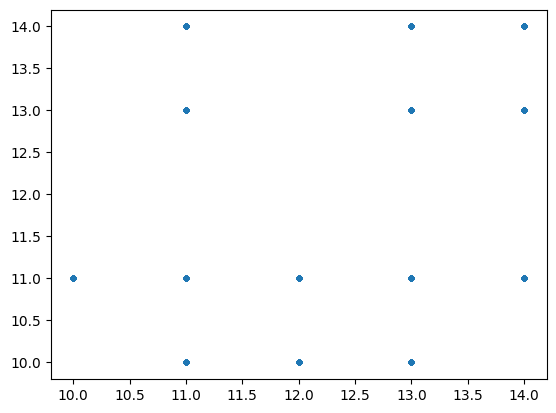

In [100]:
plt.plot(stellar_types_1, stellar_types_2, ".")

In [101]:
# let's now do this for the WDWD systems 

HeWD_bool,COWD_bool,ONeWD_bool,HeCOWD_bool,HeONeWD_bool,COHeWD_bool,COONeWD_bool,ONeHeWD_bool,ONeCOWD_bool = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged, stellar_types_2_merged)
carbon_oxygen_bool = np.logical_or(ONeCOWD_bool,np.logical_or(COONeWD_bool,np.logical_or(COHeWD_bool,np.logical_or(COWD_bool,HeCOWD_bool))))

cowd_rate = np.sum(rates_DCO_masked[carbon_oxygen_bool], axis=0)

In [103]:
print(np.sum(DCO_mask_NSNS))
print(np.sum(NSNS_systems_bool))
print(np.sum(carbon_oxygen_bool))

596806
387385
47843


In [104]:
# now the same for WDWD optimized rate
condition_mergers_WDWD = delay_times_WDWD < hubble_time
mergers_WDWD = np.sum(condition_mergers_WDWD)

# mixture_weights_merged = mixture_weights[condition_mergers_WDWD]

rates_DCO_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate'][()]
rates_DCO_masked_WDWD = rates_DCO_WDWD[condition_mergers_WDWD]

redshifts_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['redshifts'][()]

# selecting for NSNS
stellar_types_all_1_WDWD = DCOs_WDWD['Stellar_Type(1)'][()]
stellar_types_1_WDWD = stellar_types_all_1_WDWD[DCO_mask_WDWD]
stellar_types_1_merged_WDWD = stellar_types_1_WDWD[condition_mergers_WDWD]

stellar_types_all_2_WDWD = DCOs_WDWD['Stellar_Type(2)'][()]
stellar_types_2_WDWD = stellar_types_all_2_WDWD[DCO_mask_WDWD]
stellar_types_2_merged_WDWD = stellar_types_2_WDWD[condition_mergers_WDWD]

NSNS_systems_bool_WDWD = np.logical_and(stellar_types_1_merged_WDWD==13, stellar_types_2_merged_WDWD==13)
NSNS_rate_WDWD = np.sum(rates_DCO_masked_WDWD[NSNS_systems_bool_WDWD], axis=0)

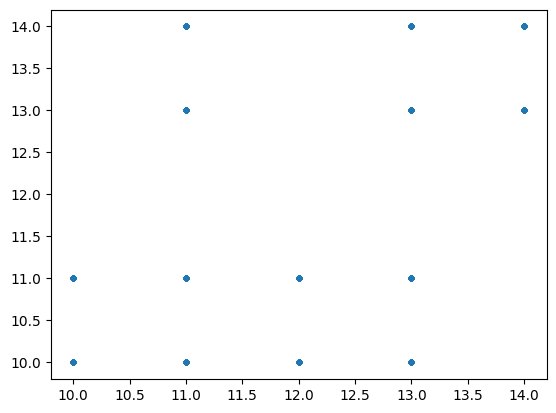

In [105]:
plt.plot(stellar_types_1_WDWD, stellar_types_2_WDWD, ".")

In [106]:
# let's now do this for the WDWD systems 

HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDWD, stellar_types_2_merged_WDWD)
carbon_oxygen_bool_WDWD = np.logical_or(ONeCOWD_bool_WDWD,np.logical_or(COONeWD_bool_WDWD,np.logical_or(COHeWD_bool_WDWD,np.logical_or(COWD_bool_WDWD,HeCOWD_bool_WDWD))))

cowd_rate_WDWD = np.sum(rates_DCO_masked_WDWD[carbon_oxygen_bool_WDWD], axis=0)

In [107]:
print(np.sum(DCO_mask_WDWD))
print(np.sum(NSNS_systems_bool_WDWD))
print(np.sum(carbon_oxygen_bool_WDWD))

2621927
1418
2496402


In [108]:
# let's now do boostrapping for each run

NSNS_rate_2D = rates_DCO_masked[NSNS_systems_bool] # NSNS optimized
percentiles = useful_fncs.bootstrapping_intervals(NSNS_rate_2D, 100, redshifts_NSNS)

Bootstrapping :[############################################################] 100/100


In [109]:
# WDWD optimized boostrapping

NSNS_rate_2D_WDWD = rates_DCO_masked_WDWD[NSNS_systems_bool_WDWD] # NSNS optimized
percentiles_WDWD = useful_fncs.bootstrapping_intervals(NSNS_rate_2D_WDWD, 100, redshifts_WDWD)

Bootstrapping :[############################################################] 100/100


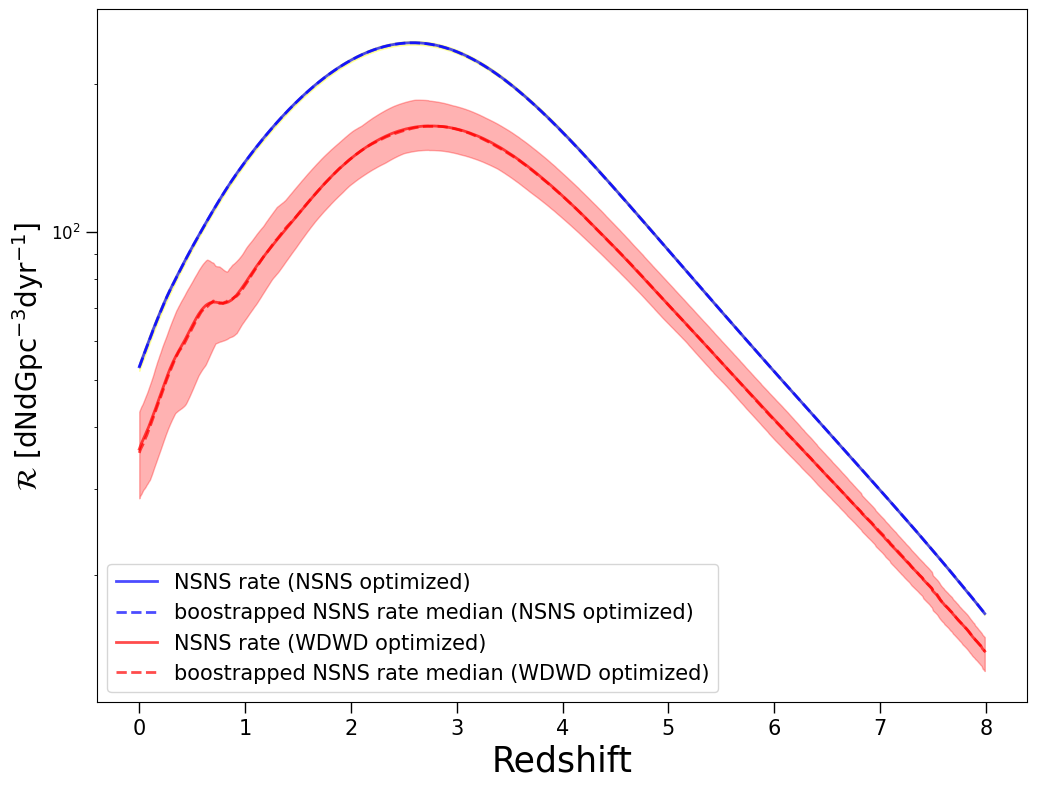

In [110]:
# let's plot the results!

#########################################
# Start plotting
fig, ax = plt.subplots(figsize = (12, 9))

cset = tc.bright

ax.fill_between(redshifts_NSNS, percentiles[0], percentiles[2], alpha = 0.3, color = 'yellow')
ax.plot(redshifts_NSNS, NSNS_rate,linewidth=2,color='blue',alpha=0.7,label='NSNS rate (NSNS optimized)')
ax.plot(redshifts_NSNS, percentiles[1],linewidth=2,color='blue', ls="--", alpha=0.7,label='boostrapped NSNS rate median (NSNS optimized)')
# some outlier that may give you high rate but when we bootstrapp we could remove the outliers and the rate can be very different 

ax.fill_between(redshifts_WDWD, percentiles_WDWD[0], percentiles_WDWD[2], alpha = 0.3, color = 'red')
ax.plot(redshifts_WDWD, NSNS_rate_WDWD,linewidth=2,color='red',alpha=0.7,label='NSNS rate (WDWD optimized)')
ax.plot(redshifts_WDWD, percentiles_WDWD[1],linewidth=2,color='red', ls="--", alpha=0.7,label='boostrapped NSNS rate median (WDWD optimized)')
# some outlier that may give you high rate but when we bootstrapp we could remove the outliers and the rate can be very different 

ax.set_yscale('log')
ax.set_ylabel(r"$\mathcal{R}$ [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]",fontsize=20)
ax.set_xlabel(r"Redshift",fontsize=25)
ax.tick_params(axis='x', length=8, width=1, labelsize=15)
ax.tick_params(axis='y', length=8, width=1, labelsize=12)
ax.legend(fontsize=15)

In [111]:
# let's now look at the WDWD rates

COWD_rate_2D = rates_DCO_masked[carbon_oxygen_bool] # NSNS optimized
percentiles_COWD_NSNSopt = useful_fncs.bootstrapping_intervals(COWD_rate_2D, 10, redshifts_NSNS)

Bootstrapping :[############################################################] 10/10


In [112]:
## WDWD optimized rate
COWD_rate_2D_WDWD = rates_DCO_masked_WDWD[carbon_oxygen_bool_WDWD] # NSNS optimized
percentiles_COWD_WDWDopt = useful_fncs.bootstrapping_intervals(COWD_rate_2D_WDWD, 10, redshifts_WDWD)

Bootstrapping :[############################################################] 10/10


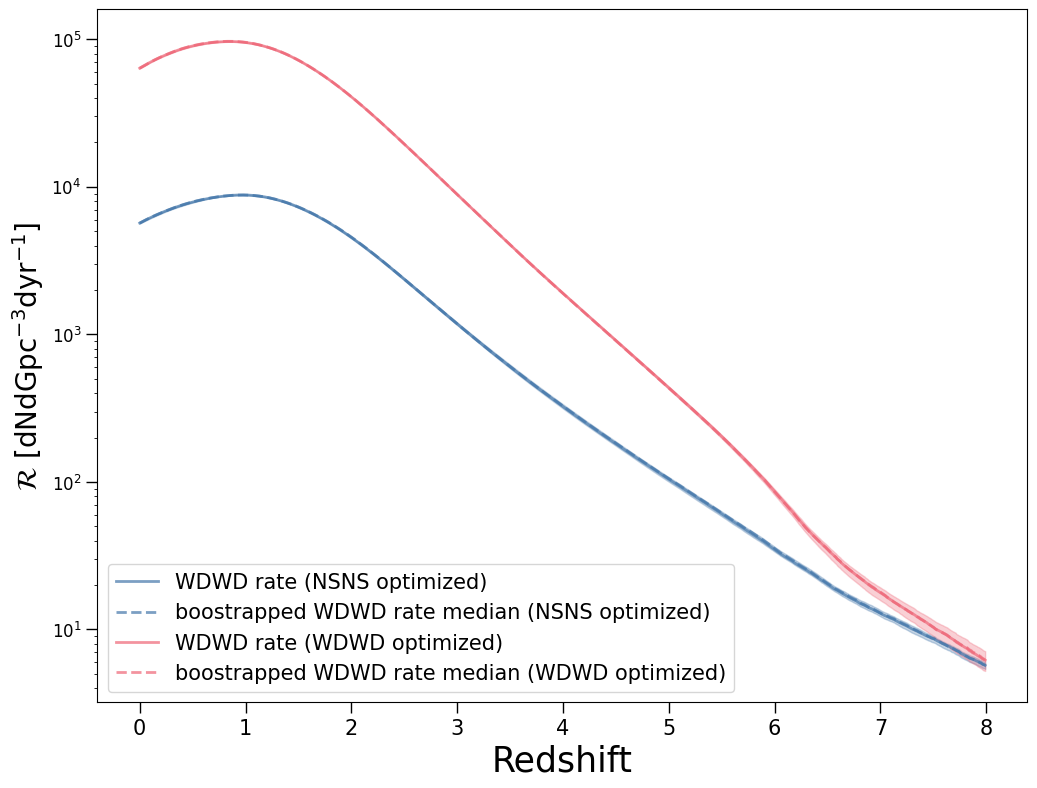

In [113]:
# let's plot the results!

#########################################
# Start plotting
fig, ax = plt.subplots(figsize = (12, 9))

cset = tc.bright

ax.fill_between(redshifts_NSNS, percentiles_COWD_NSNSopt[0], percentiles_COWD_NSNSopt[2], alpha = 0.3, color = cset.blue)
ax.plot(redshifts_NSNS, cowd_rate, linewidth=2,color=cset.blue,alpha=0.7,label='WDWD rate (NSNS optimized)')
ax.plot(redshifts_NSNS, percentiles_COWD_NSNSopt[1],linewidth=2,color=cset.blue, ls="--", alpha=0.7,label='boostrapped WDWD rate median (NSNS optimized)')
# some outlier that may give you high rate but when we bootstrapp we could remove the outliers and the rate can be very different 

ax.fill_between(redshifts_WDWD, percentiles_COWD_WDWDopt[0], percentiles_COWD_WDWDopt[2], alpha = 0.3, color = cset.red)
ax.plot(redshifts_WDWD, cowd_rate_WDWD,linewidth=2,color=cset.red,alpha=0.7,label='WDWD rate (WDWD optimized)')
ax.plot(redshifts_WDWD, percentiles_COWD_WDWDopt[1],linewidth=2,color=cset.red, ls="--", alpha=0.7,label='boostrapped WDWD rate median (WDWD optimized)')
# some outlier that may give you high rate but when we bootstrapp we could remove the outliers and the rate can be very different 

ax.set_yscale('log')
ax.set_ylabel(r"$\mathcal{R}$ [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]",fontsize=20)
ax.set_xlabel(r"Redshift",fontsize=25)
ax.tick_params(axis='x', length=8, width=1, labelsize=15)
ax.tick_params(axis='y', length=8, width=1, labelsize=12)
ax.legend(fontsize=15)

# zoom into this plot 

In [114]:
Data_NSNS.close()
Data_WDWD.close()

### Again but for Fbin = NONE

In [21]:
# let's read in our files 

## NSNS optimized run

# let's first look at the NSNS_output
pathToH5_NSNS_fixed = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS_fixed  = h5.File(pathToH5_NSNS_fixed, "r")

DCOs_NSNS_fixed = Data_NSNS_fixed['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS_fixed = Data_NSNS_fixed['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

# making sure we are rpesenting the true universe
mixture_weights_all_fixed = DCOs_NSNS_fixed['mixture_weight'][()]
mixture_weights_fixed = mixture_weights_all_fixed[DCO_mask_NSNS_fixed]

# times (these should be in Myr)
lifetimes_all_fixed = DCOs_NSNS_fixed['Time'][()]
lifetimes_fixed = lifetimes_all_fixed[DCO_mask_NSNS_fixed]

col_times_all_fixed = DCOs_NSNS_fixed['Coalescence_Time'][()]
col_times_fixed = col_times_all_fixed[DCO_mask_NSNS_fixed]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times_fixed = lifetimes_fixed + col_times_fixed


In [22]:
# doing the same for WDWD optimized rate

pathToH5_WDWD_fixed = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD_fixed  = h5.File(pathToH5_WDWD_fixed, "r")

DCOs_WDWD_fixed = Data_WDWD_fixed['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD_fixed = Data_WDWD_fixed['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

# making sure we are rpesenting the true universe
mixture_weights_all_WDWD_fixed = DCOs_WDWD_fixed['mixture_weight'][()]
mixture_weights_WDWD_fixed = mixture_weights_all_WDWD_fixed[DCO_mask_WDWD_fixed]

# times (these should be in Myr)
lifetimes_all_WDWD_fixed = DCOs_WDWD_fixed['Time'][()]
lifetimes_WDWD_fixed = lifetimes_all_WDWD_fixed[DCO_mask_WDWD_fixed]

col_times_all_WDWD_fixed = DCOs_WDWD_fixed['Coalescence_Time'][()]
col_times_WDWD_fixed = col_times_all_WDWD_fixed[DCO_mask_WDWD_fixed]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times_WDWD_fixed = lifetimes_WDWD_fixed + col_times_WDWD_fixed


In [23]:
# let's get the rates over redshifts for each run for systems that merge within a hubbble time
# let's plot the rate of the systems that merge within a hubble time

## NSNS optimized run
hubble_time = 13.9e3 # this is Myrs
condition_mergers_fixed = delay_times_fixed < hubble_time
mergers_fixed = np.sum(condition_mergers_fixed)

# mixture_weights_merged = mixture_weights[condition_mergers_fixed]

rates_DCO_fixed = Data_NSNS_fixed['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate'][()]
rates_DCO_masked_fixed = rates_DCO_fixed[condition_mergers_fixed]

redshifts_NSNS_fixed = Data_NSNS_fixed['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['redshifts'][()]

# selecting for NSNS
stellar_types_all_1_fixed = DCOs_NSNS_fixed['Stellar_Type(1)'][()]
stellar_types_1_fixed = stellar_types_all_1_fixed[DCO_mask_NSNS_fixed]
stellar_types_1_merged_fixed = stellar_types_1_fixed[condition_mergers_fixed]

stellar_types_all_2_fixed = DCOs_NSNS_fixed['Stellar_Type(2)'][()]
stellar_types_2_fixed = stellar_types_all_2_fixed[DCO_mask_NSNS_fixed]
stellar_types_2_merged_fixed = stellar_types_2_fixed[condition_mergers_fixed]

NSNS_systems_bool_fixed = np.logical_and(stellar_types_1_merged_fixed==13, stellar_types_2_merged_fixed==13)
NSNS_rate_fixed = np.sum(rates_DCO_masked_fixed[NSNS_systems_bool_fixed], axis=0)

In [5]:
# let's now do this for the WDWD systems 

HeWD_bool_fixed,COWD_bool_fixed,ONeWD_bool_fixed,HeCOWD_bool_fixed,HeONeWD_bool_fixed,COHeWD_bool_fixed,COONeWD_bool_fixed,ONeHeWD_bool_fixed,ONeCOWD_bool_fixed = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_fixed, stellar_types_2_merged_fixed)
carbon_oxygen_bool_fixed = np.logical_or(ONeCOWD_bool_fixed,np.logical_or(COONeWD_bool_fixed,np.logical_or(COHeWD_bool_fixed,np.logical_or(COWD_bool_fixed,HeCOWD_bool_fixed))))

cowd_rate_fixed = np.sum(rates_DCO_masked_fixed[carbon_oxygen_bool_fixed], axis=0)

In [24]:
# now the same for WDWD optimized rate
condition_mergers_WDWD_fixed = delay_times_WDWD_fixed < hubble_time
mergers_WDWD_fixed = np.sum(condition_mergers_WDWD_fixed)

# mixture_weights_merged = mixture_weights[condition_mergers_WDWD_fixed]

rates_DCO_WDWD_fixed = Data_WDWD_fixed['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate'][()]
rates_DCO_masked_WDWD_fixed = rates_DCO_WDWD_fixed[condition_mergers_WDWD_fixed]

redshifts_WDWD_fixed = Data_WDWD_fixed['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['redshifts'][()]

# selecting for NSNS
stellar_types_all_1_WDWD_fixed = DCOs_WDWD_fixed['Stellar_Type(1)'][()]
stellar_types_1_WDWD_fixed = stellar_types_all_1_WDWD_fixed[DCO_mask_WDWD_fixed]
stellar_types_1_merged_WDWD_fixed = stellar_types_1_WDWD_fixed[condition_mergers_WDWD_fixed]

stellar_types_all_2_WDWD_fixed = DCOs_WDWD_fixed['Stellar_Type(2)'][()]
stellar_types_2_WDWD_fixed = stellar_types_all_2_WDWD_fixed[DCO_mask_WDWD_fixed]
stellar_types_2_merged_WDWD_fixed = stellar_types_2_WDWD_fixed[condition_mergers_WDWD_fixed]

NSNS_systems_bool_WDWD_fixed = np.logical_and(stellar_types_1_merged_WDWD_fixed==13, stellar_types_2_merged_WDWD_fixed==13)
NSNS_rate_WDWD_fixed = np.sum(rates_DCO_masked_WDWD_fixed[NSNS_systems_bool_WDWD_fixed], axis=0)

In [29]:
print(np.sum(NSNS_systems_bool_WDWD_fixed))
print(np.sum(NSNS_systems_bool_fixed))

592
162650


In [7]:
# let's now do this for the WDWD systems 

HeWD_bool_WDWD_fixed,COWD_bool_WDWD_fixed,ONeWD_bool_WDWD_fixed,HeCOWD_bool_WDWD_fixed,HeONeWD_bool_WDWD_fixed,COHeWD_bool_WDWD_fixed,COONeWD_bool_WDWD_fixed,ONeHeWD_bool_WDWD_fixed,ONeCOWD_bool_WDWD_fixed = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDWD_fixed, stellar_types_2_merged_WDWD_fixed)
carbon_oxygen_bool_WDWD_fixed = np.logical_or(ONeCOWD_bool_WDWD_fixed,np.logical_or(COONeWD_bool_WDWD_fixed,np.logical_or(COHeWD_bool_WDWD_fixed,np.logical_or(COWD_bool_WDWD_fixed,HeCOWD_bool_WDWD_fixed))))

cowd_rate_WDWD_fixed = np.sum(rates_DCO_masked_WDWD_fixed[carbon_oxygen_bool_WDWD_fixed], axis=0)

In [26]:
# let's now do boostrapping for each run
## NSNS optimized run
NSNS_rate_2D_fixed = rates_DCO_masked_fixed[NSNS_systems_bool_fixed] # NSNS optimized
percentiles_fixed = useful_fncs.bootstrapping_intervals(NSNS_rate_2D_fixed, 10, redshifts_NSNS_fixed)

Bootstrapping :[############################################################] 10/10


In [27]:
# WDWD optimized boostrapping
NSNS_rate_2D_WDWD_fixed = rates_DCO_masked_WDWD_fixed[NSNS_systems_bool_WDWD_fixed] # NSNS optimized
percentiles_WDWD_fixed = useful_fncs.bootstrapping_intervals(NSNS_rate_2D_WDWD_fixed, 10, redshifts_WDWD_fixed)

Bootstrapping :[############################################################] 10/10


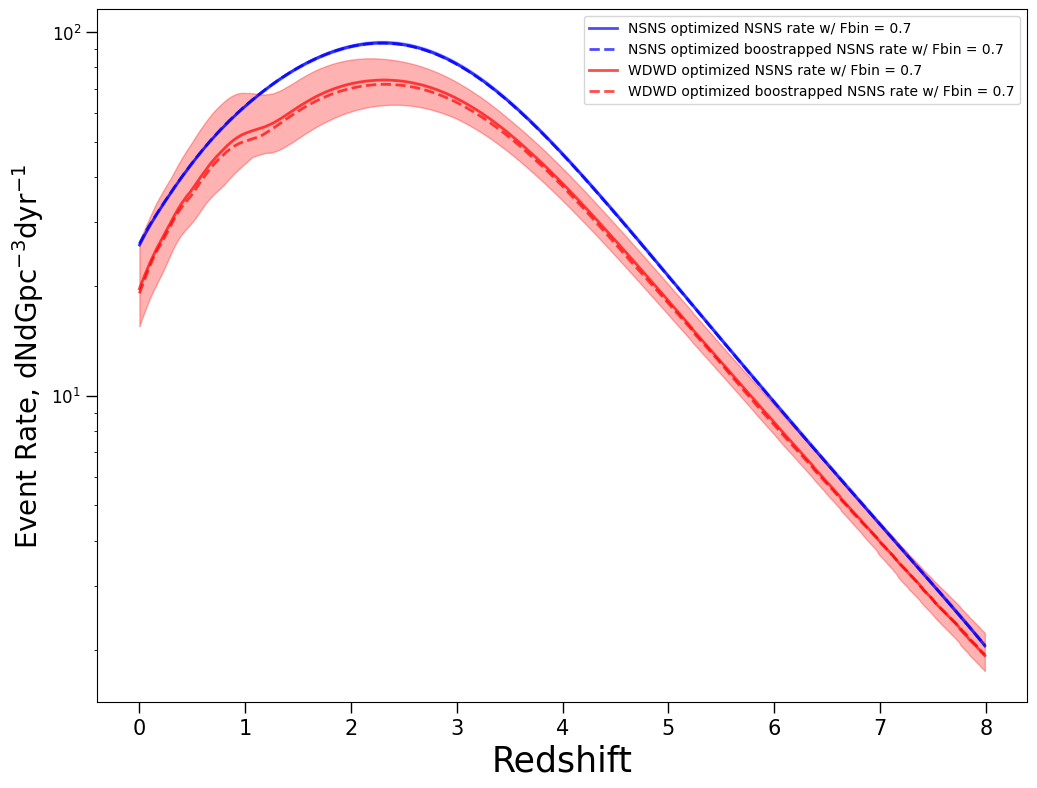

In [28]:
# let's plot the results!

#########################################
# Start plotting
fig, ax = plt.subplots(figsize = (12, 9))

cset = tc.bright

ax.fill_between(redshifts_NSNS_fixed, percentiles_fixed[0], percentiles_fixed[2], alpha = 0.3, color = 'blue')
ax.plot(redshifts_NSNS_fixed, NSNS_rate_fixed,linewidth=2,color='blue',alpha=0.7,label='NSNS optimized NSNS rate w/ Fbin = 0.7')
ax.plot(redshifts_NSNS_fixed, percentiles_fixed[1],linewidth=2,color='blue', ls="--", alpha=0.7,label='NSNS optimized boostrapped NSNS rate w/ Fbin = 0.7')
# some outlier that may give you high rate but when we bootstrapp we could remove the outliers and the rate can be very different 

ax.fill_between(redshifts_WDWD_fixed, percentiles_WDWD_fixed[0], percentiles_WDWD_fixed[2], alpha = 0.3, color = 'red')
ax.plot(redshifts_WDWD_fixed, NSNS_rate_WDWD_fixed,linewidth=2,color='red',alpha=0.7,label='WDWD optimized NSNS rate w/ Fbin = 0.7')
ax.plot(redshifts_WDWD_fixed, percentiles_WDWD_fixed[1],linewidth=2,color='red', ls="--", alpha=0.7,label='WDWD optimized boostrapped NSNS rate w/ Fbin = 0.7')
# some outlier that may give you high rate but when we bootstrapp we could remove the outliers and the rate can be very different 

ax.set_yscale('log')
ax.set_ylabel(r"Event Rate, $\mathrm{dNdGpc^{-3}dyr^{-1}}$",fontsize=20)
ax.set_xlabel(r"Redshift",fontsize=25)
ax.tick_params(axis='x', length=8, width=1, labelsize=15)
ax.tick_params(axis='y', length=8, width=1, labelsize=12)
ax.legend()

In [12]:
# let's now look at WDWD rates
COWD_rate_2D_fixed = rates_DCO_masked_fixed[carbon_oxygen_bool_fixed] # NSNS optimized
percentiles_COWD_NSNSopt_fixed = useful_fncs.bootstrapping_intervals(COWD_rate_2D_fixed, 10, redshifts_NSNS_fixed)

Bootstrapping :[############################################################] 10/10


In [13]:
## WDWD optimized rate
COWD_rate_2D_WDWD_fixed = rates_DCO_masked_WDWD_fixed[carbon_oxygen_bool_WDWD_fixed] # NSNS optimized
percentiles_COWD_WDWDopt_fixed = useful_fncs.bootstrapping_intervals(COWD_rate_2D_WDWD_fixed, 10, redshifts_WDWD_fixed)

Bootstrapping :[############################################################] 10/10


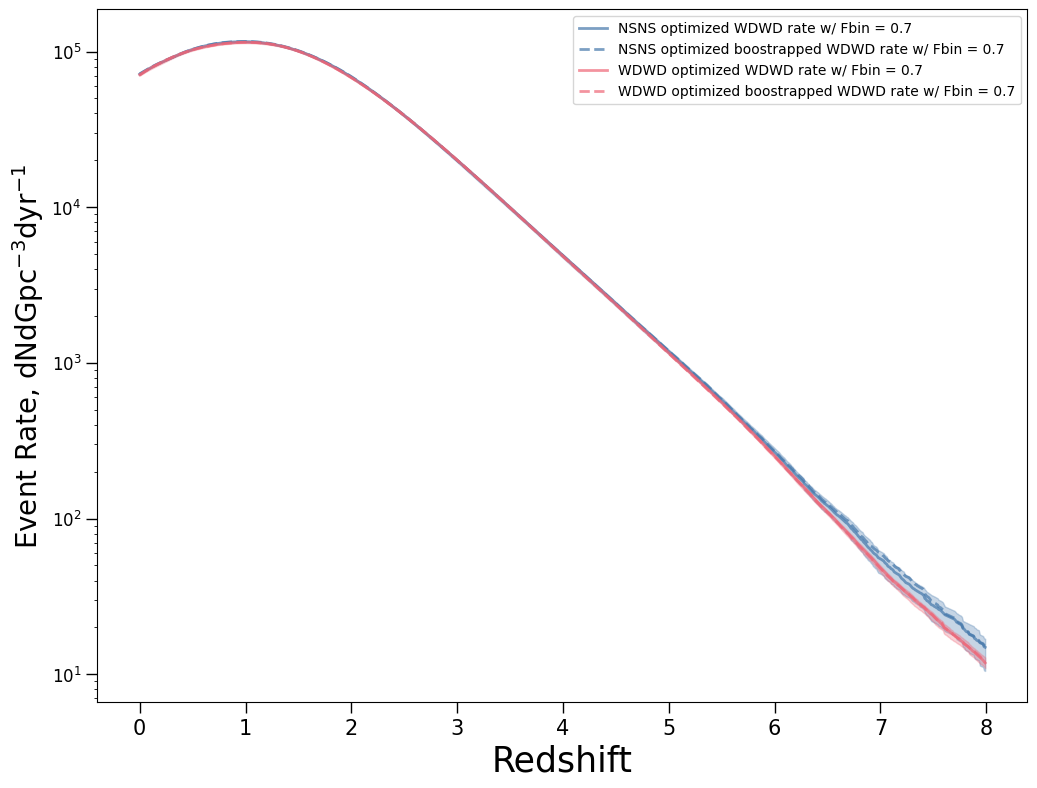

In [14]:
# let's plot the results!

#########################################
# Start plotting
fig, ax = plt.subplots(figsize = (12, 9))

cset = tc.bright

ax.fill_between(redshifts_NSNS_fixed, percentiles_COWD_NSNSopt_fixed[0], percentiles_COWD_NSNSopt_fixed[2], alpha = 0.3, color = cset.blue)
ax.plot(redshifts_NSNS_fixed, cowd_rate_fixed, linewidth=2,color=cset.blue,alpha=0.7,label='NSNS optimized WDWD rate w/ Fbin = 0.7')
ax.plot(redshifts_NSNS_fixed, percentiles_COWD_NSNSopt_fixed[1],linewidth=2,color=cset.blue, ls="--", alpha=0.7,label='NSNS optimized boostrapped WDWD rate w/ Fbin = 0.7')
# some outlier that may give you high rate but when we bootstrapp we could remove the outliers and the rate can be very different 

ax.fill_between(redshifts_WDWD_fixed, percentiles_COWD_WDWDopt_fixed[0], percentiles_COWD_WDWDopt_fixed[2], alpha = 0.3, color = cset.red)
ax.plot(redshifts_WDWD_fixed, cowd_rate_WDWD_fixed,linewidth=2,color=cset.red,alpha=0.7,label='WDWD optimized WDWD rate w/ Fbin = 0.7')
ax.plot(redshifts_WDWD_fixed, percentiles_COWD_WDWDopt_fixed[1],linewidth=2,color=cset.red, ls="--", alpha=0.7,label='WDWD optimized boostrapped WDWD rate w/ Fbin = 0.7')
# some outlier that may give you high rate but when we bootstrapp we could remove the outliers and the rate can be very different 

ax.set_yscale('log')
ax.set_ylabel(r"Event Rate, $\mathrm{dNdGpc^{-3}dyr^{-1}}$",fontsize=20)
ax.set_xlabel(r"Redshift",fontsize=25)
ax.tick_params(axis='x', length=8, width=1, labelsize=15)
ax.tick_params(axis='y', length=8, width=1, labelsize=12)
ax.legend()

In [15]:
# checking to make sure m1min is what i set for fci
DCOs_SPs_NSNS_fixed = Data_NSNS_fixed['BSE_System_Parameters'] # getting the DCO objects
print(min(DCOs_SPs_NSNS_fixed['Mass@ZAMS(1)']))
print(max(DCOs_SPs_NSNS_fixed['Mass@ZAMS(1)']))

1.000001107722762
149.9686776415753


In [16]:
# checking to make sure m1min is what i set for fci
DCOs_SPs_WDWD_fixed = Data_WDWD_fixed['BSE_System_Parameters'] # getting the DCO objects
print(min(DCOs_SPs_WDWD_fixed['Mass@ZAMS(1)']))
print(max(DCOs_SPs_WDWD_fixed['Mass@ZAMS(1)']))

1.0000018441464844
149.21601955876218


In [13]:
# closing the data files
Data_NSNS_fixed.close()
Data_WDWD_fixed.close()